# HOT-NERD Lung Cancer Tutorial

This notebook demonstrates the complete HOT-NERD pipeline on a Xenium lung adenocarcinoma dataset, performing cell segmentation refinement from spatial transcriptomics data.

## Dataset

**Xenium Lung Adenocarcinoma Dataset**

The data is from:
> Takano, Y., Suzuki, J., Nomura, K. et al. Spatially resolved gene expression profiling of tumor microenvironment reveals key steps of lung adenocarcinoma development. *Nat Commun* **15**, 10637 (2024). https://doi.org/10.1038/s41467-024-54671-7

This dataset provides high-resolution spatial transcriptomics of lung adenocarcinoma tissue, enabling detailed analysis of the tumor microenvironment and cancer progression.

## Pipeline Overview

The notebook executes the full HOT-NERD workflow:

1. **Conservative NPMI Pruning** - Remove low-quality transcripts based on gene co-expression patterns
2. **Component Annotation** - Graph-based detection and annotation of unassigned transcripts
3. **Hierarchical Stitching** - Merge partial cells and components into complete cell boundaries
4. **Spatial Coherence Enforcement** - Ensure cell assignments are spatially connected
5. **Final Refinement** - Re-stitch to produce final high-quality cell segmentation

## Performance Notes

This notebook uses **Cython-accelerated functions** (`_fast` variants) that reduce runtime from hours to minutes:
- `prune_transcripts_fast` with parallel processing
- `annotate_unassigned_components_fast` with bulk Cython pruning
- `enforce_spatial_coherence_fast` with C-level connected components

Run the next code cell to set up the Cython environment, imports, and helper functions.

In [14]:
# optional: install/enable Cython at runtime (run once if wheel not built)
%pip install --upgrade Cython

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pyximport, numpy, sys
import importlib
pyximport.install(setup_args={"include_dirs": [numpy.get_include()]},
                  language_level=3, build_in_temp=False)
sys.path.insert(0, "src")
import hotnerd.core as core
importlib.reload(core)   # ensures pyximport compilation runs
print("cython available:", core._cy_prune is not None)
print("cython _cy_spatial available:", getattr(core, "_cy_spatial", None) is not None)

/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cython available: True
cython _cy_spatial available: True


In [2]:
import sys
from pathlib import Path
import pandas as pd
import traceback

# ensure repo src on path
repo_root = Path.cwd()
sys.path.insert(0, str(repo_root / "src"))

# robust parquet reader helper
def read_parquet_robust(path: Path):
    try:
        return pd.read_parquet(path)
    except Exception as e:
        print("pd.read_parquet failed:", e)
        try:
            import pyarrow.parquet as pq
            import pyarrow as pa
            files = [path] if not path.is_dir() else sorted(path.glob("*.parquet"))
            tables = []
            for f in files:
                print("Reading parquet file:", f)
                pf = pq.ParquetFile(str(f))
                tbl = pf.read()
                tables.append(tbl)
            if not tables:
                raise RuntimeError("No parquet files found for fallback read")
            return pa.concat_tables(tables).to_pandas()
        except Exception:
            traceback.print_exc()
            raise


In [3]:
# Data paths (adjust if notebook root differs)
DATA_DIR = repo_root / "data"
PARQUET_PATH = DATA_DIR / "lung_cancer_df.parquet"
NPMI_CSV = DATA_DIR / "lung_cancer_npmi.csv"

print('parquet:', PARQUET_PATH)
print('npmi:', NPMI_CSV)

# Read data
print('Reading transcripts...')
df_transcripts = read_parquet_robust(PARQUET_PATH)
print('Transcripts rows:', len(df_transcripts))

print('Reading NPMI...')
df_npmi = pd.read_csv(NPMI_CSV)
print('NPMI rows:', len(df_npmi))

parquet: /Users/lyuan13/Desktop/HOT-NERD/tutorials/lung_cancer/data/lung_cancer_df.parquet
npmi: /Users/lyuan13/Desktop/HOT-NERD/tutorials/lung_cancer/data/lung_cancer_npmi.csv
Reading transcripts...
Transcripts rows: 1436900
Reading NPMI...
NPMI rows: 44100


In [4]:
# Run conservative pruning
print('Running prune_transcripts (conservative NPMI pruning)')

# df_transcripts and df_npmi are loaded earlier in this notebook
df_pruned, aux = core.prune_transcripts_fast(
    df_transcripts,
    df_npmi,
    cell_id_col="cell_id",
    gene_col="feature_name",
    threshold=-0.1,
    unassigned_id="-1",
    n_jobs=-1,            # adjust for your machine (-1 for all cores handled inside)
    show_progress=True,  # enable tqdm progress bars
)
print('Done. pruned rows:', len(df_pruned))
df_pruned.head()

Running prune_transcripts (conservative NPMI pruning)


prune_pass2: 100%|██████████| 50564/50564 [00:00<00:00, 208127.00it/s]


Done. pruned rows: 1436900


,x,y,z,feature_name,cell_id,nucleus_distance,transcript_id,fov_name,qv,overlaps_nucleus,cell_id_npmi_cons_p1,npmi_cons_p1_status,cell_id_npmi_cons_p2,npmi_cons_p2_status
0,90.116203,1481.733154,11.636851,MZB1,-1,141.229370,281509336450057,D6,40.000000,0,-1,unassigned_input,-1,unchanged
1,148.954025,1657.631226,11.568077,VAMP8,-1,140.643250,281509336449024,D6,40.000000,0,-1,unassigned_input,-1,unchanged
2,138.317154,1597.401001,11.680394,RORC,-1,102.513069,281509336449738,D6,40.000000,0,-1,unassigned_input,-1,unchanged
3,162.937073,1656.976318,11.793150,RORC,-1,133.364517,281509336449739,D6,40.000000,0,-1,unassigned_input,-1,unchanged
4,56.945526,1596.405273,11.688915,HEPACAM2,-1,174.493057,281509336449800,D6,39.681641,0,-1,unassigned_input,-1,unchanged


In [5]:
df_final = core.annotate_unassigned_components_fast(
    df_pruned,            # DataFrame returned from prune_transcripts_fast
    aux,                  # aux dict returned from prune_transcripts_fast
    build_graph_fn=core.build_graph,
    prune_fn=core.prune_genes_by_npmi_greedy,
    coord_cols=("x","y","z"),
    k=8,
    dist_threshold=1.5,
    min_comp_size=10,
    npmi_threshold=-0.2,
    unassigned_final_col="cell_id_npmi_cons_p2",
    cell_id_col="cell_id",
    gene_col="feature_name",
    transcript_id_col="transcript_id",
    show_progress=True,   # enable tqdm
)

Constructed 52,900 edges among 162,747 transcripts (k≤8, d≤1.5 µm)


post_cc_mapping: : 4it [00:00, 540.40it/s]                         
grouping: 100%|██████████| 2/2 [00:00<00:00, 321.70it/s]


[INFO] Using Cython-accelerated pruning (40 components)


prune_comps: 100%|██████████| 40/40 [00:00<00:00, 51.95it/s]


In [6]:
df_stitched, entity_to_stitched = core.apply_stitching_to_transcripts_fast(
    df_final=df_final,          # DataFrame (output of annotate_unassigned_components/_fast)
    aux=aux,                    # aux dict from prune_transcripts(_fast)
    entity_col="cell_id_final",
    gene_col="feature_name",
    coord_cols=("x","y","z"),
    tau=0.05,
    use_relu=True,
    penalize_simplicity=True,
    deltaC_min=0.0,
    use_3d=True,
    out_col="cell_id_stitched",
    show_progress=True,         # tqdm progress
)

stitching: 100%|██████████| 2/2 [02:25<00:00, 72.57s/it]


In [7]:
df_spatial = core.enforce_spatial_coherence_fast(
    df_stitched,                        # DataFrame produced by apply_stitching_to_transcripts(_fast)
    build_graph_fn=core.build_graph,
    entity_col="cell_id_stitched",      # label column to check
    coord_cols=("x", "y", "z"),
    k=5,
    dist_threshold=20.0,
    out_col="cell_id_spatial",
    show_progress=True,                 # show tqdm progress
)

Constructed 7,178,993 edges among 1,436,900 transcripts (k≤5, d≤20.0 µm)


spatial_labels: 100%|██████████| 58475/58475 [00:31<00:00, 1864.16it/s]


In [8]:
df_finetuned, entity_to_stitched_ft = core.apply_stitching_to_transcripts_fast(
    df_final=df_spatial,          # DataFrame (output of enforce_spatial_coherence_fast)
    aux=aux,
    entity_col="cell_id_spatial",
    gene_col="feature_name",
    coord_cols=("x", "y", "z"),
    tau=0.05,
    use_relu=True,
    penalize_simplicity=True,
    deltaC_min=0.0,
    use_3d=True,
    out_col="cell_id_finetuned",
    show_progress=True,   
)

stitching: 100%|██████████| 2/2 [11:46<00:00, 353.14s/it]


In [9]:
df_finetuned, n_reassigned, stats = core.reassign_unassigned_to_nearby_entities_fast(
    df_finetuned,
    entity_summary=None,  # Auto-build from df_finetuned
    entity_col='cell_id_finetuned',
    gene_col='feature_name',
    coord_cols=('x', 'y', 'z'),
    out_col='cell_id_finetuned_2',
    dist_threshold=20.0,  # Max distance for reassignment
    only_partial_component=False,  # Don't assign to 'cell' type
    show_progress=True,
)

print(f"Reassigned {n_reassigned} transcripts")
print(f"Mean reassignment distance: {stats['mean_distance']:.2f}")

Building entity summary...
Phase 6: Reassigned 160749/162238 unassigned transcripts (threshold=20.0)
  Mean distance: 4.29, Max distance: 19.99
Reassigned 160749 transcripts
Mean reassignment distance: 4.29


In [10]:
from pathlib import Path

out_dir = repo_root / "output"
out_dir.mkdir(parents=True, exist_ok=True)

fp_stitched = out_dir / "df_stitched.parquet"
fp_finetuned = out_dir / "df_finetuned.parquet"

df_stitched.to_parquet(fp_stitched, index=False)
df_finetuned.to_parquet(fp_finetuned, index=False)

print("Saved df_stitched ->", fp_stitched)
print("Saved df_finetuned ->", fp_finetuned)

Saved df_stitched -> /Users/lyuan13/Desktop/HOT-NERD/tutorials/lung_cancer/output/df_stitched.parquet
Saved df_finetuned -> /Users/lyuan13/Desktop/HOT-NERD/tutorials/lung_cancer/output/df_finetuned.parquet


In [4]:
import scipy.sparse as sp
import scanpy as sc
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [5]:
cols = ["cell_id", "cell_id_stitched", "cell_id_finetuned", "cell_id_finetuned_2"]

unassigned_counts = (df_finetuned[cols] == -1).sum()
print(unassigned_counts)

cell_id                1822
cell_id_stitched          0
cell_id_finetuned         0
cell_id_finetuned_2       0
dtype: int64


In [22]:
cols = ["cell_id", "cell_id_stitched", "cell_id_finetuned", "cell_id_finetuned_2"]

unassigned_counts = (df_finetuned[cols] == 'DROP').sum()
print(unassigned_counts)

cell_id                     0
cell_id_stitched       126862
cell_id_finetuned      126862
cell_id_finetuned_2       108
dtype: int64


In [14]:
subset = df_finetuned[df_finetuned["cell_id"] == -1]
feature_counts = subset["feature_name"].value_counts()

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=200
)

wc = wc.generate_from_frequencies(feature_counts)

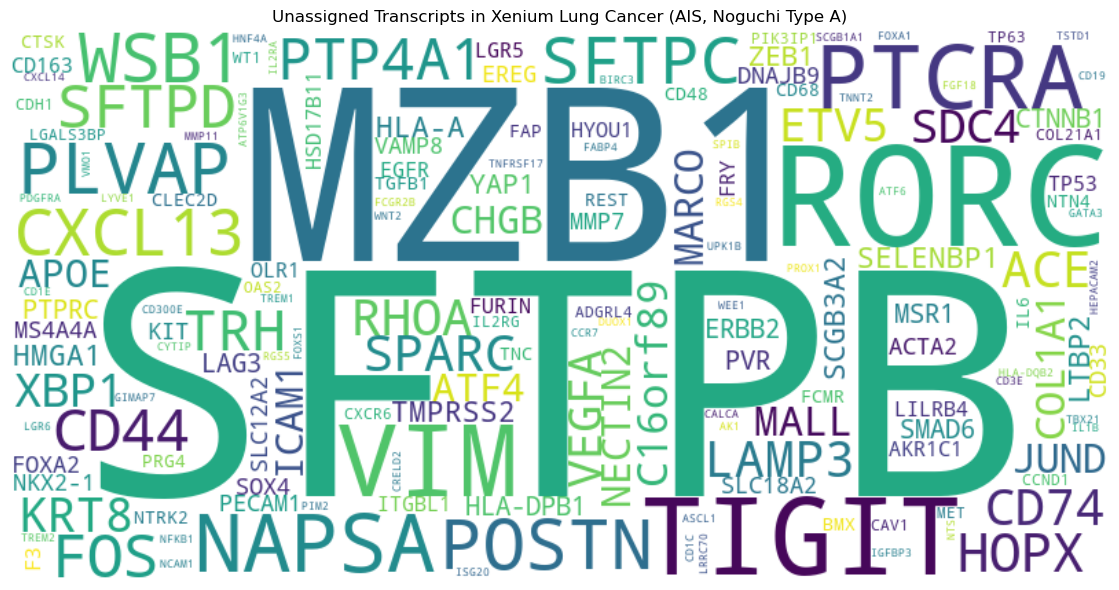

In [15]:
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Unassigned Transcripts in Xenium Lung Cancer (AIS, Noguchi Type A)")
plt.tight_layout()
plt.savefig("plot/lung_cancer_unassigned_transcripts.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
subset = df_finetuned[df_finetuned["cell_id_finetuned"] == 'DROP']
feature_counts = subset["feature_name"].value_counts()

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=200
)

wc = wc.generate_from_frequencies(feature_counts)

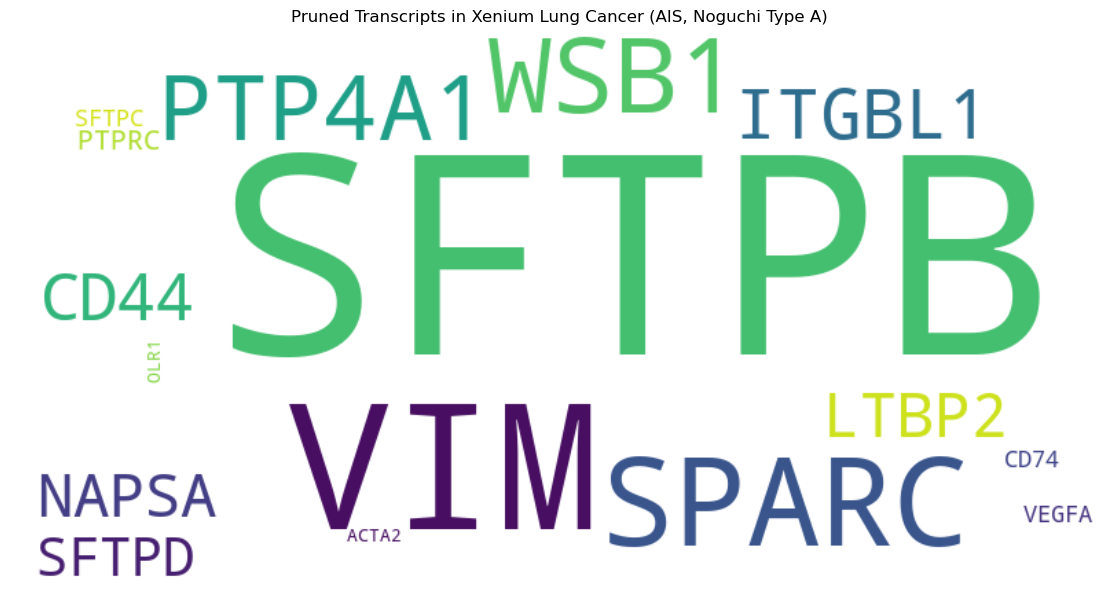

In [17]:
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Pruned Transcripts in Xenium Lung Cancer (AIS, Noguchi Type A)")
plt.tight_layout()
plt.savefig("plot/lung_cancer_pruned_transcripts.png", dpi=600, bbox_inches="tight")
plt.show()

In [7]:
subset = df_finetuned[df_finetuned["cell_id_finetuned_2"] == 'DROP']
feature_counts = subset["feature_name"].value_counts()

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=200
)

wc = wc.generate_from_frequencies(feature_counts)


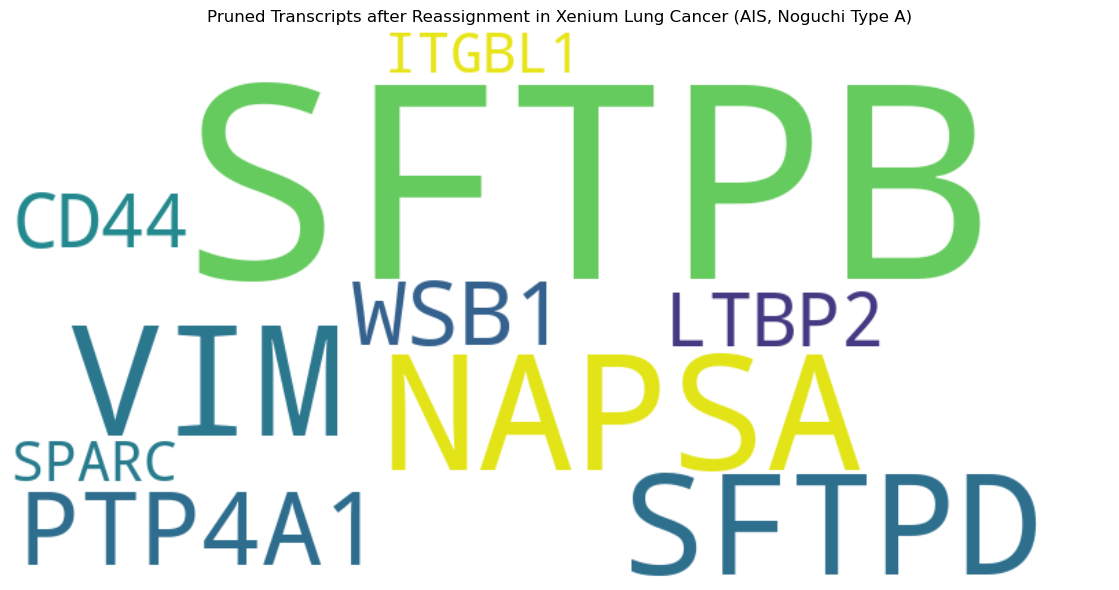

In [8]:
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Pruned Transcripts after Reassignment in Xenium Lung Cancer (AIS, Noguchi Type A)")
plt.tight_layout()
plt.savefig("plot/lung_cancer_pruned_transcripts_after_reassignment.png", dpi=600, bbox_inches="tight")
plt.show()